In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Para que no salgan alertas rojas QUE ME TIENEN PODRIDO

# 1. Cargar la base de datos que hemos construido
df = pd.read_csv('../data/raw/FTP.csv')

# Mostrar las primeras filas para confirmar que todo va ok
display(df.head())

,ClubName,LeagueName,Country,SquadMarketValue,StadiumCapacity,ForeignersPercentage,NationalTeamPlayers,AveragePlayerAge,AveragePlayerHeight,TotalPlayers,TotalGoals,TotalWins,TotalDraws,TotalLosses,MatchesPlayed,TotalYellowCards,TotalRedCards,TotalAssists,TotalMinutesPlayed
0,Arminia Bielefeld,bundesliga,Germany,12.500,26515,55.6,4,29.727273,183.571429,22,140.0,34.0,21.0,47.0,102.0,115.0,2.0,54.0,70521.0
1,Paris Football Club,ligue-1,France,134.350,19904,54.8,8,28.709677,181.161290,31,32.0,7.0,10.0,10.0,27.0,52.0,2.0,20.0,26491.0
2,Esporte Clube Bahia,campeonato-brasileiro-serie-a,Brazil,114.600,47364,18.2,3,26.411765,181.272727,34,50.0,17.0,10.0,10.0,37.0,NaN,NaN,NaN,NaN
3,Leicester City,premier-league,England,155.975,32259,58.6,9,30.851351,182.878788,74,687.0,184.0,96.0,181.0,461.0,691.0,10.0,481.0,435690.0
4,Unione Sportiva Lecce,serie-a,Italy,120.030,31559,85.2,10,26.805556,185.000000,72,229.0,57.0,50.0,106.0,213.0,391.0,16.0,138.0,188927.0


In [7]:
# Verificamos los tipos de datos y si hay nulos
print("INFORMACIÓN GENERAL DEL DATASET:")
print("-" * 50)
df.info()

print("\n" + "="*50)

# Separamos las variables automáticamente por su tipo
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n✅ Variables Numéricas ({len(num_cols)}):")
for col in num_cols: print(f"  - {col}")

print(f"\n✅ Variables Categóricas ({len(cat_cols)}):")
for col in cat_cols: print(f"  - {col}")

INFORMACIÓN GENERAL DEL DATASET:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788 entries, 0 to 787
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ClubName              788 non-null    object 
 1   LeagueName            788 non-null    object 
 2   Country               788 non-null    object 
 3   SquadMarketValue      788 non-null    float64
 4   StadiumCapacity       788 non-null    int64  
 5   ForeignersPercentage  732 non-null    float64
 6   NationalTeamPlayers   788 non-null    int64  
 7   AveragePlayerAge      788 non-null    float64
 8   AveragePlayerHeight   788 non-null    float64
 9   TotalPlayers          788 non-null    int64  
 10  TotalGoals            783 non-null    float64
 11  TotalWins             783 non-null    float64
 12  TotalDraws            783 non-null    float64
 13  TotalLosses           783 non-null    flo

In [8]:
# Estadísticas descriptivas de las variables numéricas
# Transponemos (.T) para que sea más fácil de leer de arriba a abajo
estadisticas = df[num_cols].describe().T

# Añadimos la Mediana (que es el percentil 50%) para tenerla clara
estadisticas['mediana'] = df[num_cols].median()

# Reorganizamos las columnas para que se vea como nos piden
estadisticas = estadisticas[['count', 'mean', 'mediana', 'std', 'min', 'max']]
estadisticas.columns = ['Conteo', 'Media', 'Mediana', 'Desv_Estandar', 'Minimo', 'Maximo']

print("ESTADÍSTICAS DESCRIPTIVAS BÁSICAS:")
display(estadisticas.round(2))

ESTADÍSTICAS DESCRIPTIVAS BÁSICAS:


,Conteo,Media,Mediana,Desv_Estandar,Minimo,Maximo
SquadMarketValue,788.0,77.59,23.75,162.82,0.20,1369.18
StadiumCapacity,788.0,24338.08,20043.00,17489.19,0.00,85018.00
ForeignersPercentage,732.0,41.01,40.70,20.57,2.40,100.00
NationalTeamPlayers,788.0,4.04,3.00,4.44,0.00,22.00
AveragePlayerAge,788.0,29.11,28.13,3.87,22.92,42.00
AveragePlayerHeight,788.0,181.98,182.18,1.98,172.14,187.00
TotalPlayers,788.0,56.97,45.00,33.44,1.00,198.00
TotalGoals,783.0,275.67,117.00,346.58,1.00,1971.00
TotalWins,783.0,75.34,30.00,100.71,0.00,546.00
TotalDraws,783.0,44.36,21.00,45.73,0.00,177.00


📊 GENERANDO HISTOGRAMAS DE TODAS LAS VARIABLES NUMÉRICAS...


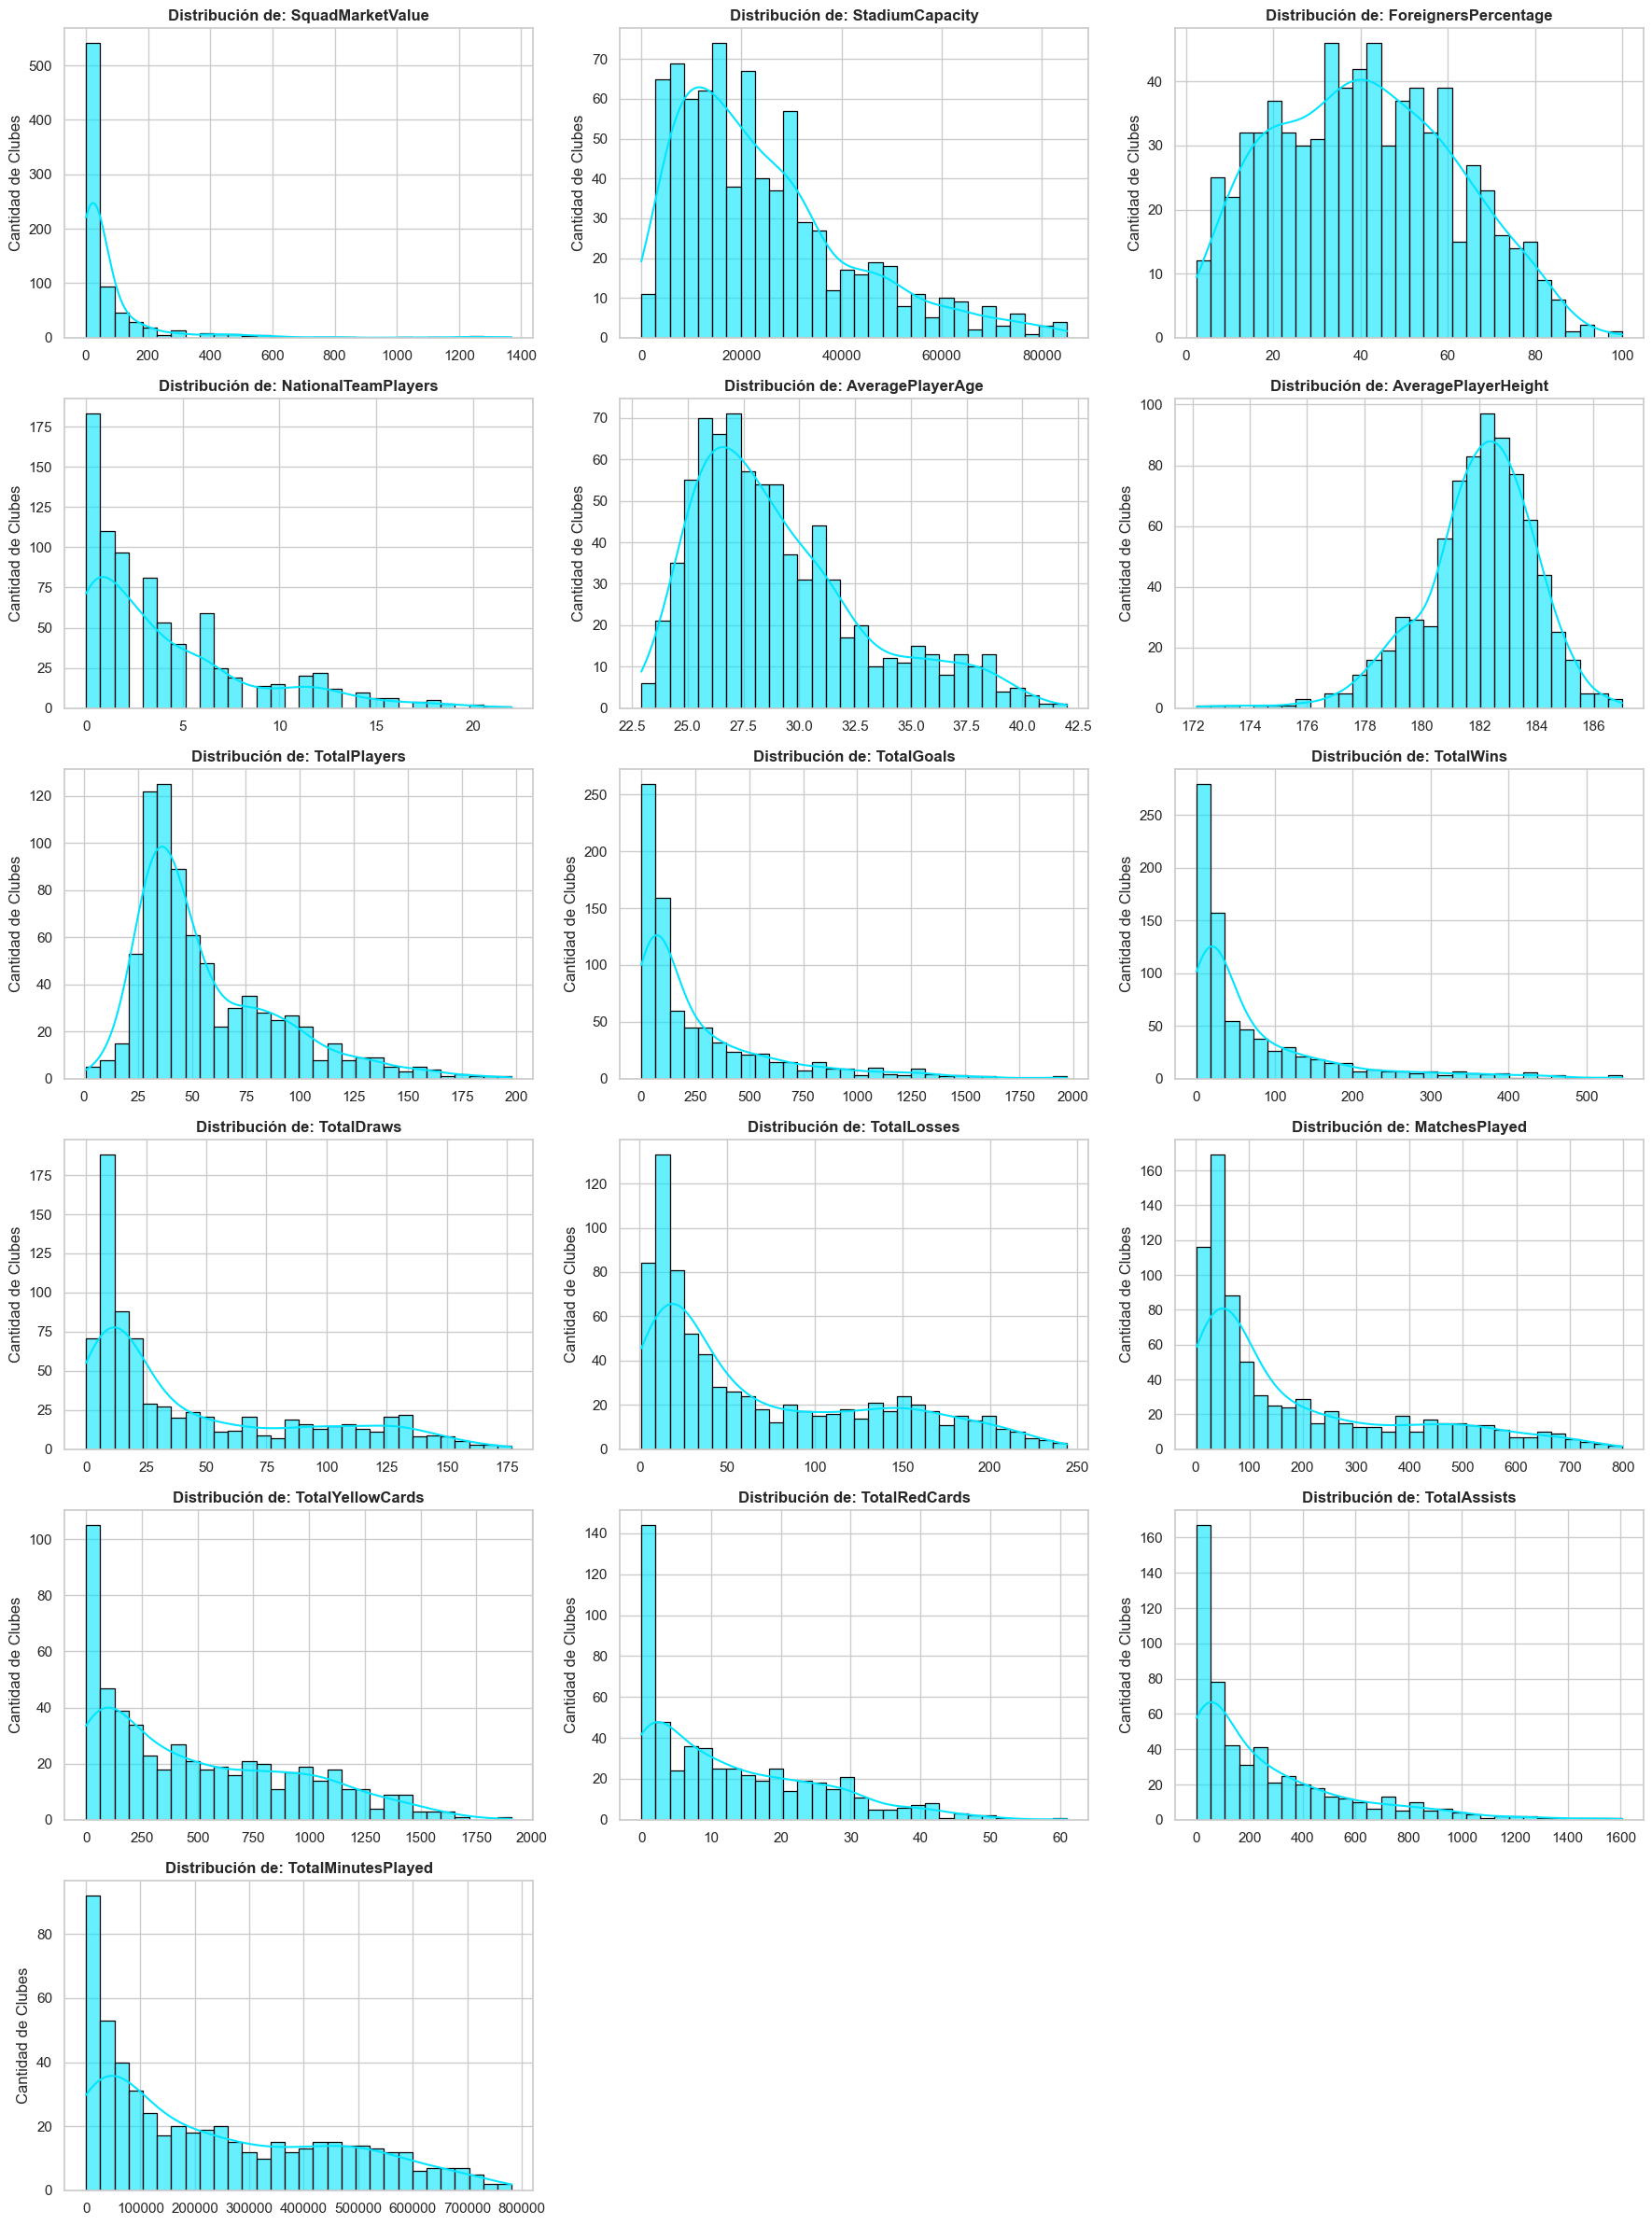

In [9]:
import math

# Configuramos un estilo melo
sns.set_theme(style="whitegrid")

# Usamos la lista de variables numéricas que sacamos en el paso 1
columnas_a_graficar = num_cols 

# Calculamos cuántas filas necesitamos para la cuadrícula (3 gráficos por fila en este caso)
n_cols_grid = 3
n_rows_grid = math.ceil(len(columnas_a_graficar) / n_cols_grid)

# Creamos la figura
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, 4 * n_rows_grid))
axes = axes.flatten() # Aplanamos el array de ejes para iterar fácilmente


#Mensajito
print("📊 GENERANDO HISTOGRAMAS DE TODAS LAS VARIABLES NUMÉRICAS...")

# Bucle: recorre cada variable y le dibuja su histograma
for i, col in enumerate(columnas_a_graficar):
    # kde=True dibuja la línea curva de tendencia
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i], color='#00e5ff', edgecolor='black', alpha=0.6)
    axes[i].set_title(f'Distribución de: {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de Clubes')

# Si sobran espacios vacíos en la cuadrícula al final, los borramos para que se vea pulcro
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustamos el espaciado para que los títulos no se choquen
plt.tight_layout()
plt.show()

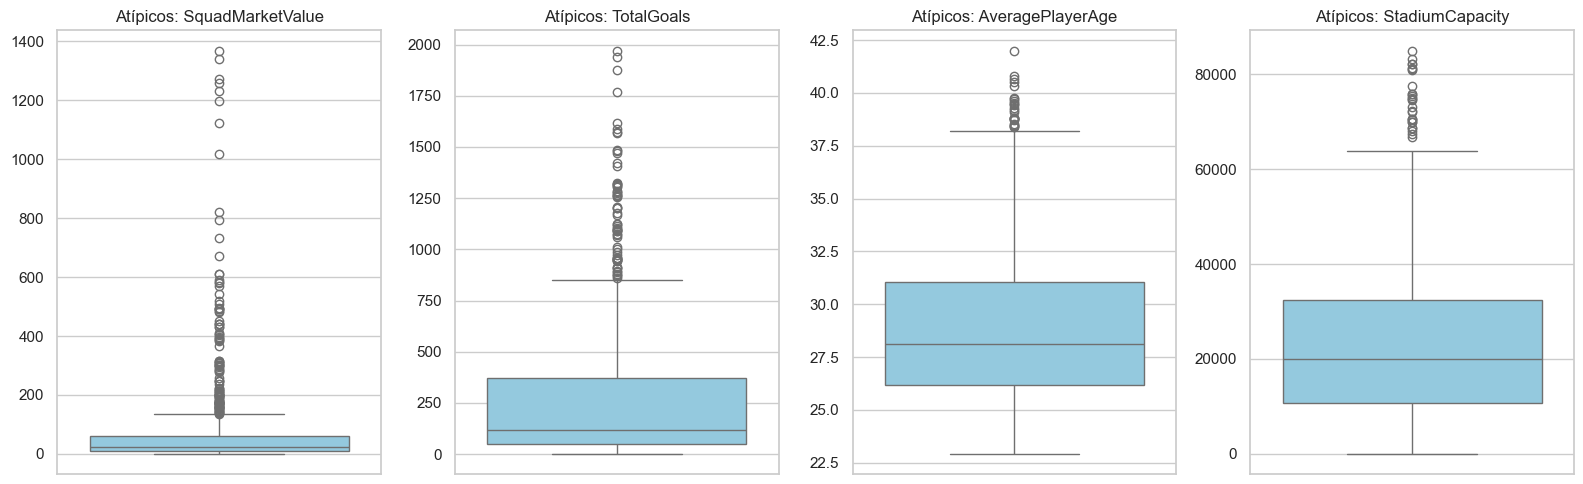

In [10]:
# 3. Identificación de valores atípicos (Gráficos Boxplot)
# Seleccionamos algunas variables clave para no saturar la pantalla
variables_atipicos = ['SquadMarketValue', 'TotalGoals', 'AveragePlayerAge', 'StadiumCapacity']

plt.figure(figsize=(16, 5))
for i, col in enumerate(variables_atipicos, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Atípicos: {col}')
    plt.ylabel('') # Quitamos la etiqueta Y para que se vea mejor

plt.tight_layout()
plt.show()

In [11]:
# Cálculo exacto de atípicos (Método IQR)
print("CANTIDAD EXACTA DE VALORES ATÍPICOS POR VARIABLE:")
print("-" * 50)

for col in num_cols: # Usamos num_cols de la Celda 2
    # Calculamos Cuartil 1 y Cuartil 3 ignorando los nulos
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Definimos las fronteras matemáticas
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Contamos cuántas filas se salen de esos límites
    atipicos = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    cantidad = len(atipicos)
    
    if cantidad > 0:
        print(f"🔸 {col}: {cantidad} clubes atípicos ({(cantidad/len(df))*100:.1f}%)")

CANTIDAD EXACTA DE VALORES ATÍPICOS POR VARIABLE:
--------------------------------------------------
🔸 SquadMarketValue: 108 clubes atípicos (13.7%)
🔸 StadiumCapacity: 27 clubes atípicos (3.4%)
🔸 NationalTeamPlayers: 38 clubes atípicos (4.8%)
🔸 AveragePlayerAge: 25 clubes atípicos (3.2%)
🔸 AveragePlayerHeight: 20 clubes atípicos (2.5%)
🔸 TotalPlayers: 23 clubes atípicos (2.9%)
🔸 TotalGoals: 64 clubes atípicos (8.1%)
🔸 TotalWins: 71 clubes atípicos (9.0%)
🔸 TotalDraws: 2 clubes atípicos (0.3%)
🔸 MatchesPlayed: 17 clubes atípicos (2.2%)
🔸 TotalRedCards: 3 clubes atípicos (0.4%)
🔸 TotalAssists: 26 clubes atípicos (3.3%)


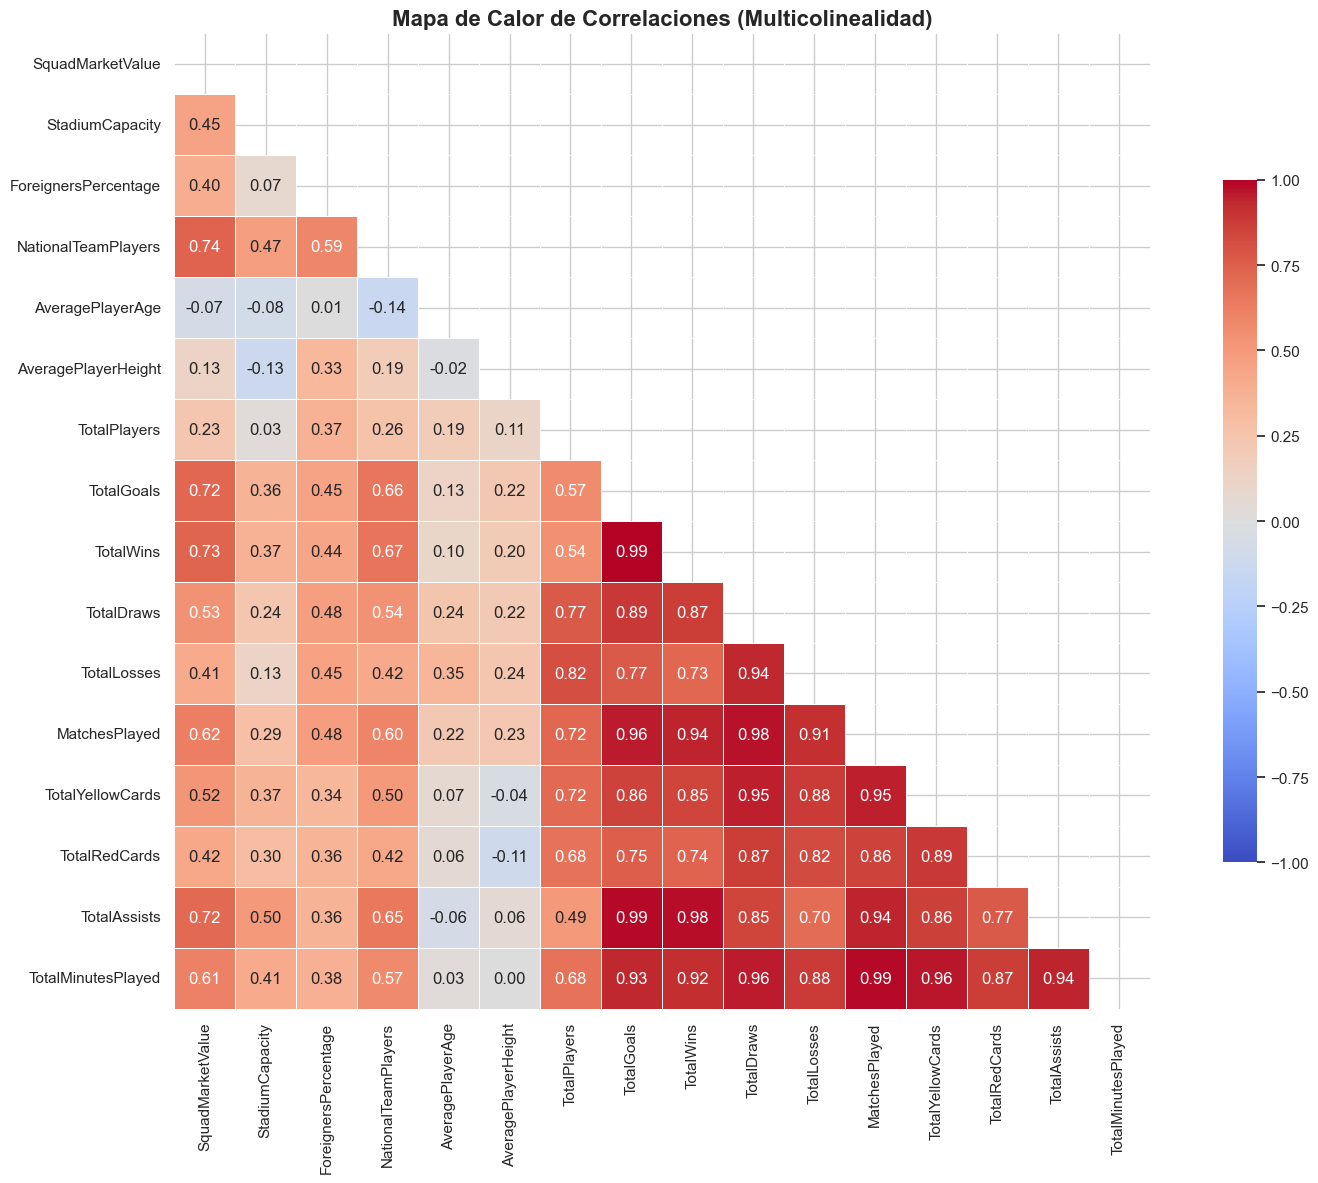

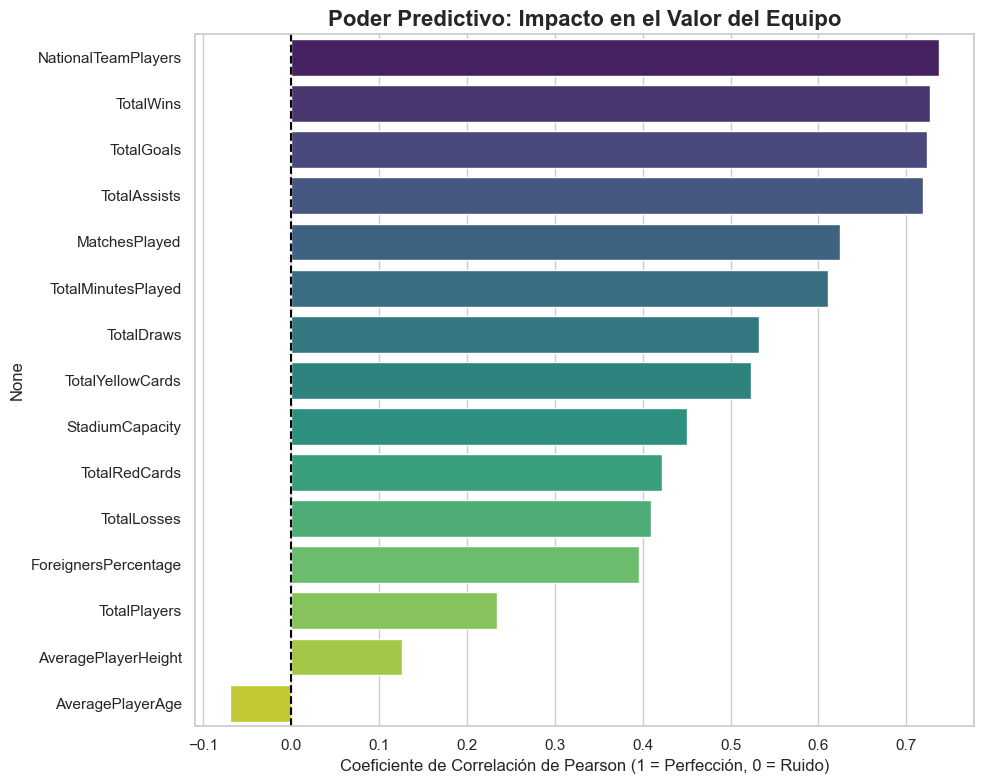

In [12]:
# 4. Análisis de Correlación

# Calculamos la matriz de correlación de Pearson (solo con las numéricas)
corr_matrix = df[num_cols].corr()

# ---------------------------------------------------------
# GRÁFICO 1: Mapa de Calor (Heatmap) Triangular
# ---------------------------------------------------------
plt.figure(figsize=(16, 12))

# Creamos una máscara para ocultar la mitad superior (porque es un espejo de la inferior no paorta nada)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Dibujamos el mapa de calor
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title('Mapa de Calor de Correlaciones (Multicolinealidad)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

# ---------------------------------------------------------
# GRÁFICO 2: Correlación directa con el Target (SquadMarketValue)
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# Extraemos la columna del Target, la ordenamos y quitamos el Target en sí (que obvio es 1.0)
corr_target = corr_matrix['SquadMarketValue'].sort_values(ascending=False).drop('SquadMarketValue')

# Creamos un gráfico de barras horizontales
sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')

plt.title('Poder Predictivo: Impacto en el Valor del Equipo', fontsize=16, fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson (1 = Perfección, 0 = Ruido)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # Línea en el cero para separar positivos de negativos

plt.tight_layout()
plt.show()

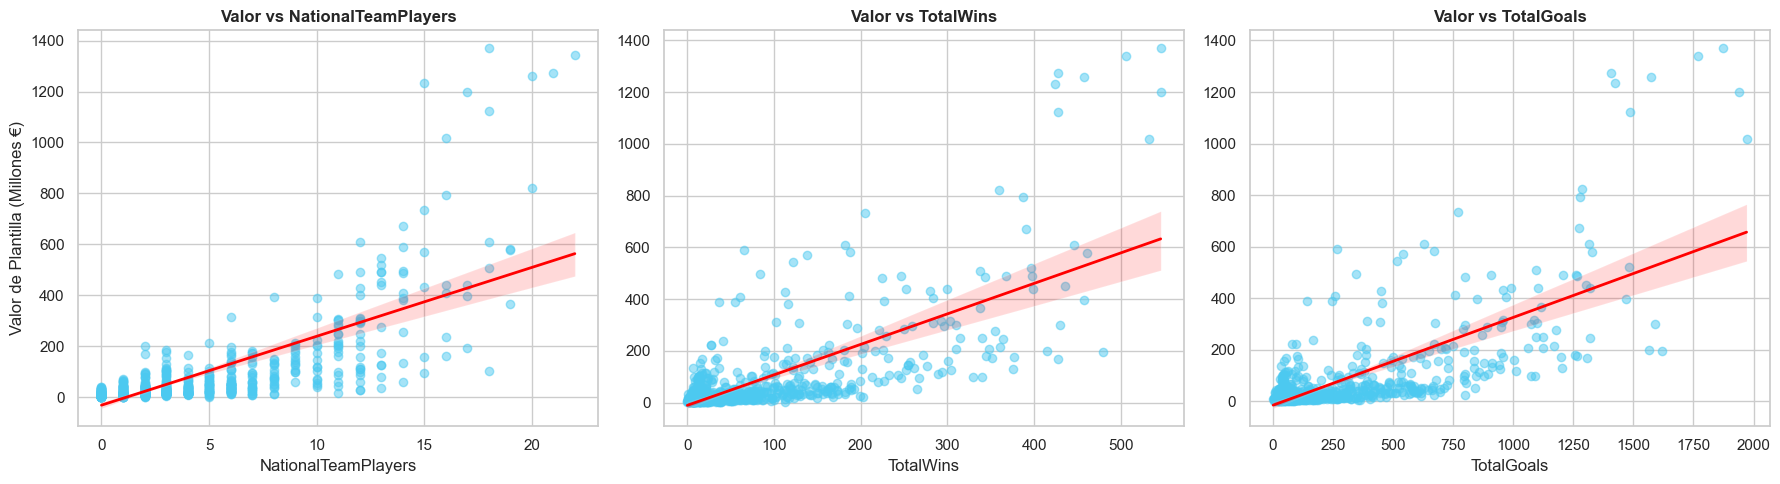

In [14]:
# 5. Análisis de relaciones entre variables (Scatter plots)

# Vamos a graficar las 3 mejores variables predictoras contra el Target

mejores_predictoras = ['NationalTeamPlayers', 'TotalWins', 'TotalGoals']

plt.figure(figsize=(18, 5))
sns.set_theme(style="whitegrid")

for i, col in enumerate(mejores_predictoras, 1):
    plt.subplot(1, 3, i)
    
    # Scatter plot con línea de regresión integrada (regplot)
    sns.regplot(data=df, x=col, y='SquadMarketValue', 
                scatter_kws={'alpha':0.5, 'color':'#4cc9f0'}, 
                line_kws={'color':'red', 'linewidth':2})
    
    plt.title(f'Valor vs {col}', fontweight='bold')
    plt.ylabel('Valor de Plantilla (Millones €)' if i == 1 else '')

plt.tight_layout()
plt.show()

In [15]:
# 1. Identificar valores faltantes
print("REPORTE DE VALORES FALTANTES:")
print("-" * 30)
null_report = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

missing_data = pd.concat([null_report, null_percent], axis=1, keys=['Total Nulos', '% Nulos'])
display(missing_data[missing_data['Total Nulos'] > 0])

REPORTE DE VALORES FALTANTES:
------------------------------


,Total Nulos,% Nulos
ForeignersPercentage,56,7.106599
TotalGoals,5,0.634518
TotalWins,5,0.634518
TotalDraws,5,0.634518
TotalLosses,5,0.634518
MatchesPlayed,5,0.634518
TotalYellowCards,246,31.218274
TotalRedCards,246,31.218274
TotalAssists,246,31.218274
TotalMinutesPlayed,246,31.218274


In [16]:
from sklearn.impute import SimpleImputer, KNNImputer

# Creamos copias para comparar métodos después
df_median = df.copy()
df_knn = df.copy()

# Variables numéricas con nulos (basado en el reporte anterior)
cols_con_nulos = ['TotalYellowCards', 'TotalRedCards', 'TotalAssists', 'TotalMinutesPlayed']

# --- MÉTODO A: Medidas de tendencia central (Mediana) ---
imputer_median = SimpleImputer(strategy='median')
df_median[cols_con_nulos] = imputer_median.fit_transform(df_median[cols_con_nulos])

# --- MÉTODO B: KNN Imputer (Basado en similitud entre clubes) ---
# KNN usa la distancia entre filas para estimar el valor faltante
imputer_knn = KNNImputer(n_neighbors=5)
df_knn[num_cols] = imputer_knn.fit_transform(df_knn[num_cols])

📊 COMPARATIVA DE MEDIAS (Antes vs Después):
------------------------------------------------------------
🔹 TotalYellowCards:
   - Original: 498.31
   - Mediana:  463.56
   - KNN:      425.02

🔹 TotalRedCards:
   - Original: 12.96
   - Mediana:  11.72
   - KNN:      11.01

🔹 TotalAssists:
   - Original: 256.65
   - Mediana:  221.01
   - KNN:      216.05

🔹 TotalMinutesPlayed:
   - Original: 234532.46
   - Mediana:  215581.73
   - KNN:      199761.62



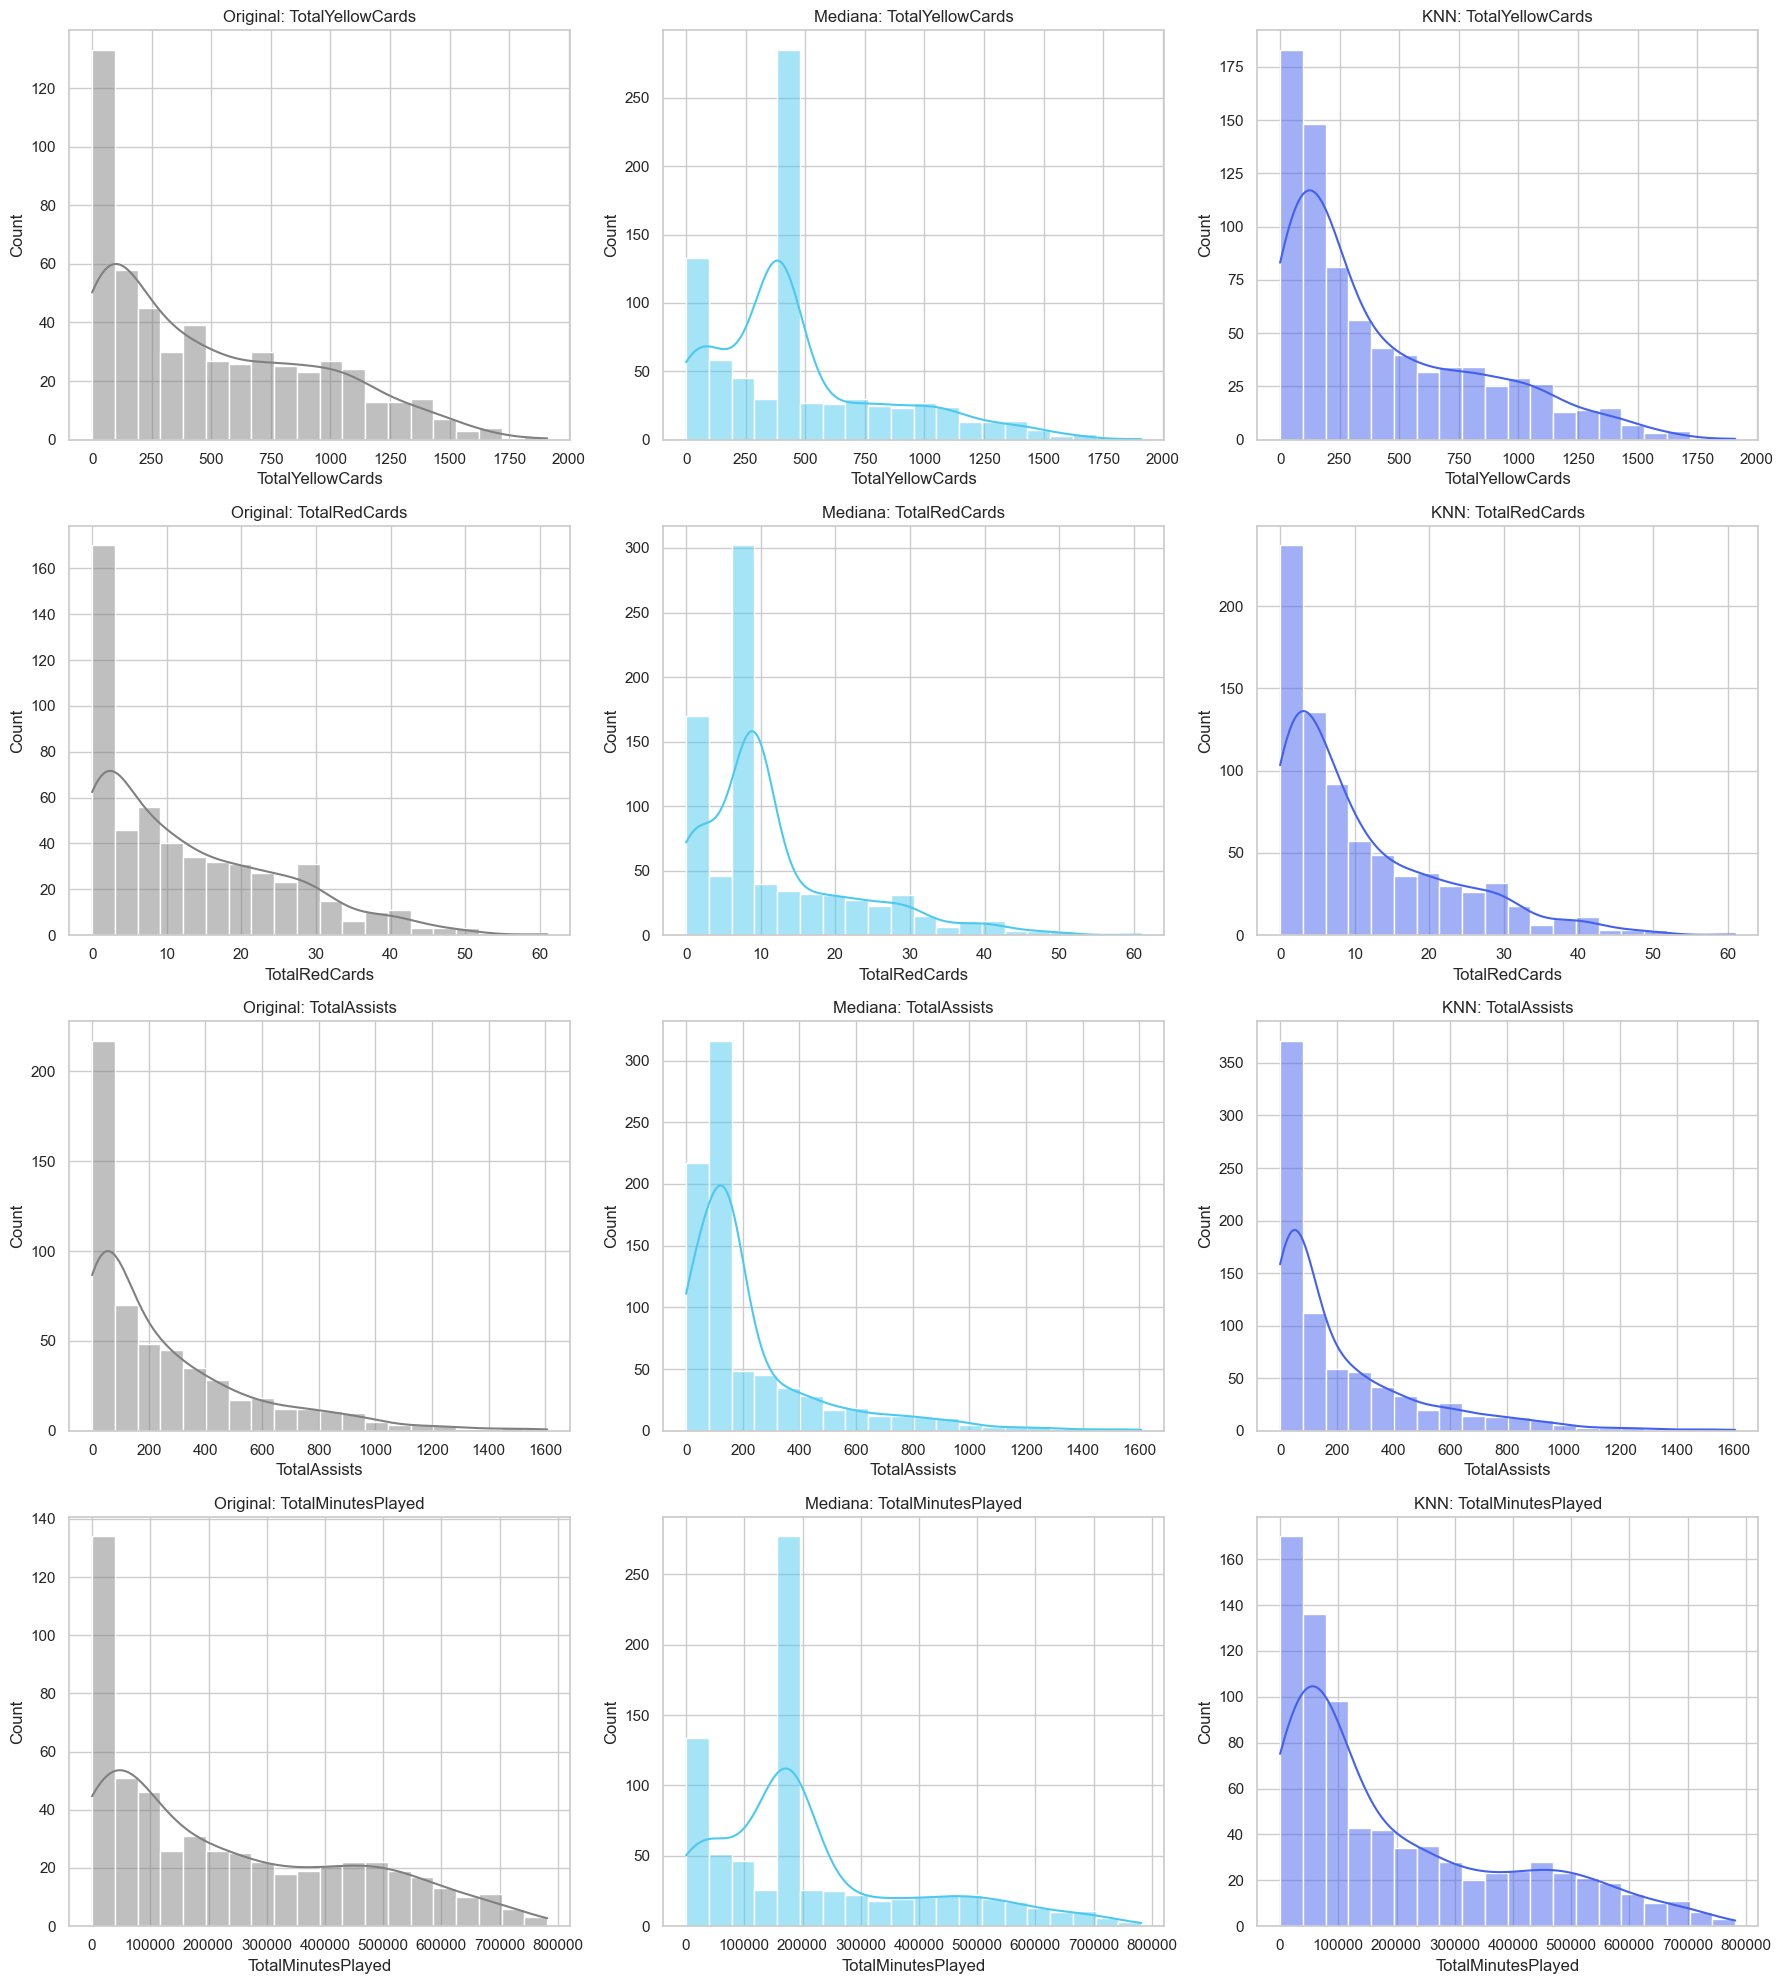

In [17]:
# Definimos las 4 columnas que tienen nulos
cols_faltantes = ['TotalYellowCards', 'TotalRedCards', 'TotalAssists', 'TotalMinutesPlayed']

# --- 1. Generamos las comparaciones estadísticas ---
print("📊 COMPARATIVA DE MEDIAS (Antes vs Después):")
print("-" * 60)

for col in cols_faltantes:
    original_mean = df[col].mean()
    median_mean = df_median[col].mean()
    knn_mean = df_knn[col].mean()
    
    print(f"🔹 {col}:")
    print(f"   - Original: {original_mean:.2f}")
    print(f"   - Mediana:  {median_mean:.2f}")
    print(f"   - KNN:      {knn_mean:.2f}\n")

# --- 2. Visualización Masiva (Histogramas Comparativos) ---
# Creamos una cuadrícula de 4 filas (una por variable) y 3 columnas (Original, Mediana, KNN)
fig, axes = plt.subplots(len(cols_faltantes), 3, figsize=(18, 20))

for i, col in enumerate(cols_faltantes):
    # Columna 1: Original (con nulos)
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='gray', bins=20)
    axes[i, 0].set_title(f'Original: {col}')
    
    # Columna 2: Imputación por Mediana
    sns.histplot(df_median[col], kde=True, ax=axes[i, 1], color='#4cc9f0', bins=20)
    axes[i, 1].set_title(f'Mediana: {col}')
    
    # Columna 3: Imputación por KNN
    sns.histplot(df_knn[col], kde=True, ax=axes[i, 2], color='#4361ee', bins=20)
    axes[i, 2].set_title(f'KNN: {col}')

plt.tight_layout()
plt.show()

Tras analizar las distribuciones comparativas, se determina que el método de KNN Imputer (K-Nearest Neighbors) es el más adecuado para el tratamiento de datos faltantes en este dataset por las siguientes razones:

1) A diferencia de la imputación por Mediana, que genera picos en los datos, el mpetodo de KNN mantiene la forma original de la distribución y la varianza, lo cual es fundamental para que el modelo de regresión no se sesgue hacia valores centrales.

2) KNN estima los valores faltantes analizando clubes con características similares (presupuesto, goles, edad promedio). Esto es mucho más preciso que asignar un promedio global, ya que un club de la Premier League con datos faltantes debería parecerse más a sus pares de élite que a un club de una liga menor.


In [18]:
import os
import pandas as pd
# 1. Crear la carpeta 'processed' si no existe
ruta_processed = '../data/processed/'
os.makedirs(ruta_processed, exist_ok=True)

# 2. Guardar el dataset de fútbol limpio e imputado
# Usamos df_knn porque es el que decidimos que era mejor
df_knn.to_csv(os.path.join(ruta_processed, 'FTP_limpio.csv'), index=False)

In [2]:
import pandas as pd
from scipy import stats

# 1. Cargar los datos ya procesados
df_futbol = pd.read_csv('../data/processed/FTP_limpio.csv')

# 2. Definir función de tu guía (Pág 8)
def pruebas_correlacion(df, var_x, var_y, alpha=0.05):
    x, y = df[var_x], df[var_y]
    corr_p, p_p = stats.pearsonr(x, y) # Pearson: Relación Lineal
    corr_s, p_s = stats.spearmanr(x, y) # Spearman: Relación Monótona
    
    print(f"📊 PRUEBAS PARA: {var_x} vs {var_y}")
    print(f"Pearson  -> Corr: {corr_p:.4f}, p-value: {p_p:.6e}")
    print(f"Spearman -> Corr: {corr_s:.4f}, p-value: {p_s:.6e}")
    
    if p_p < alpha: print("✅ Existe relación lineal significativa")
    else: print("❌ No hay evidencia de relación lineal")
    print("-" * 30)

# 3. Ejecutar para tus variables estrella
predictoras = ['NationalTeamPlayers', 'TotalGoals', 'MatchesPlayed']
for col in predictoras:
    pruebas_correlacion(df_futbol, col, 'SquadMarketValue')

📊 PRUEBAS PARA: NationalTeamPlayers vs SquadMarketValue
Pearson  -> Corr: 0.7367, p-value: 1.133823e-135
Spearman -> Corr: 0.7640, p-value: 1.025233e-151
✅ Existe relación lineal significativa
------------------------------
📊 PRUEBAS PARA: TotalGoals vs SquadMarketValue
Pearson  -> Corr: 0.7237, p-value: 9.922925e-129
Spearman -> Corr: 0.5835, p-value: 4.466750e-73
✅ Existe relación lineal significativa
------------------------------
📊 PRUEBAS PARA: MatchesPlayed vs SquadMarketValue
Pearson  -> Corr: 0.6245, p-value: 1.998435e-86
Spearman -> Corr: 0.5374, p-value: 3.576536e-60
✅ Existe relación lineal significativa
------------------------------


In [9]:
import pandas as pd
from scipy import stats
import os

# 1. CARGAR LOS DATOS (Para solucionar el NameError)
# Cargamos el archivo que guardamos en la carpeta processed
ruta_csv = '../data/processed/FTP_limpio.csv'
df = pd.read_csv(ruta_csv)

# 2. DEFINIR LA FUNCIÓN (Basada en Pág. 24 de tu guía)
def kruskal_test_liga(data, x_cat, y_cont, alpha=0.05):
    """
    Realiza la prueba de Kruskal-Wallis para una variable categórica y una continua.
    """
    # Identificamos los grupos únicos en la variable categórica 
    categorias = data[x_cat].dropna().unique()
    
    # Creamos los grupos de datos para la prueba 
    grupos = [data[data[x_cat] == cat][y_cont].dropna() for cat in categorias]
    
    # Ejecutamos la prueba de Kruskal-Wallis 
    H, p = stats.kruskal(*grupos)
    
    print(f"📊 TEST KRUSKAL-WALLIS: {x_cat} vs {y_cont}")
    print(f"Estadístico H: {H:.4f}")
    print(f"p-value: {p:.6e}")
    
    # Interpretación según el nivel de significancia (alpha) 
    if p < alpha:
        print("✅ Se rechaza H0: Existen diferencias significativas entre grupos (Hay dependencia).")
    else:
        print("❌ No se rechaza H0: No hay evidencia de diferencias (Son independientes).")

# 3. EJECUCIÓN DINÁMICA (Para solucionar el KeyError)
# Intentamos con 'comp_name', si falla, buscamos el nombre correcto automáticamente
col_liga = 'comp_name' 

if col_liga not in df.columns:
    # Si 'comp_name' no existe, buscamos columnas que contengan 'comp' o 'league'
    posibles = [c for c in df.columns if 'comp' in c.lower() or 'league' in c.lower()]
    if posibles:
        col_liga = posibles[0]
        print(f"⚠️ 'comp_name' no encontrada. Usando la columna detectada: '{col_liga}'\n")
    else:
        print("❌ No se encontró la columna de la Liga. Columnas disponibles:", df.columns.tolist())

# Ejecutar test final
kruskal_test_liga(df, col_liga, 'SquadMarketValue')

⚠️ 'comp_name' no encontrada. Usando la columna detectada: 'LeagueName'

📊 TEST KRUSKAL-WALLIS: LeagueName vs SquadMarketValue
Estadístico H: 201.6289
p-value: 3.369740e-28
✅ Se rechaza H0: Existen diferencias significativas entre grupos (Hay dependencia).


-------------------------------------------------------------------------------------------------
                Interpretación de Pruebas de Asociación y Dependencia (Regresión)
-------------------------------------------------------------------------------------------------

Después de ejecutar las pruebas de hipótesis, vamos a analizar los resultados para poder 
determinar qué variables aportan información relevante al valor de mercado (SquadMarketValue):

##############################################   ##############################################
A. Variables Numéricas (Pearson y Spearman)      B. Variables Mixtas (Prueba de Kruskal-Wallis)
##############################################   ##############################################

|////////////////////////////////////////////|   |////////////////////////////////////////////|
|  Desempeño y Estatus vs. Valor de Mercado  |   |         Liga (LeagueName) vs. Valor        |
|////////////////////////////////////////////|   |////////////////////////////////////////////|
| Se evaluaron 3 predictoras clave y todas   |   | Se obtuvo un p-value = 3.36e-28 (≈ 0).     |
| arrojaron p-values ≈ 0, rechazando H_0:    |   | Al ser muchísimo menor al nivel de         |
|                                            |   | significancia α = 0.05, se rechaza H_0.    |
| 1. NationalTeamPlayers: Relación monótona  |   |                                            |
| fuerte (Spearman = 0.76).                  |   | Esto confirma una dependencia estadística  |
| 2. TotalGoals: Relación lineal             |   | muy fuerte; el valor económico de las      |
| fuerte (Pearson = 0.72).                   |   | plantillas varía drásticamente             |
| 3. MatchesPlayed: Relación moderada        |   | dependiendo de la competición.             |
| (Pearson = 0.62).                          |   |                                            |
|                                            |   |                                            |
| Conclusión: Son variables indispensables   |   | Conclusión: La liga es un factor de        |
| para el modelo predictivo de regresión.    |   | segmentación crítico para la regresión.    |
|////////////////////////////////////////////|   |////////////////////////////////////////////|